# Cross-Asset Momentum Strategy

## 1. Data Exploration

This notebook constructs and explores the historical market dataset used for the cross-asset momentum strategy.

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

### Investment Universe

The strategy uses liquid ETFs as proxies for four major asset classes:

- Equities: SPY, EFA
- Fixed Income: IEF, TLT
- Foreign Exchange: UUP
- Commodities: GLD, DBC

In [4]:
tickers = ["SPY", "EFA", "IEF", "TLT", "UUP", "GLD", "DBC"]

prices = yf.download(tickers, start="2007-01-01", auto_adjust=True)["Close"]

prices.head()

[*********************100%***********************]  7 of 7 completed


Ticker,DBC,EFA,GLD,IEF,SPY,TLT,UUP
Date,,,,,,,
2007-01-03,19.330030,41.088039,62.279999,49.960869,98.624588,48.048351,NaN
2007-01-04,18.826475,40.970661,61.650002,50.142178,98.833870,48.339695,NaN
2007-01-05,18.761501,40.355824,60.169998,49.978989,98.045578,48.129314,NaN
2007-01-08,18.858963,40.411716,60.480000,50.015259,98.499031,48.215622,NaN
2007-01-09,18.696524,40.450840,60.849998,50.003159,98.415306,48.215622,NaN


In [5]:
prices.tail()

Ticker,DBC,EFA,GLD,IEF,SPY,TLT,UUP
Date,,,,,,,
2026-09-17,33.049999,106.040001,398.359985,91.250000,760.710999,81.779999,28.379999
2026-09-18,32.930000,104.970001,401.170013,90.800003,761.690002,81.250000,28.389999
2026-09-21,32.580002,106.129997,398.380005,91.150002,773.500000,81.800003,28.480000
2026-09-22,NaN,NaN,400.070007,NaN,773.380005,81.750000,NaN
2026-09-23,32.880001,104.800003,392.880005,90.190002,767.809998,80.459999,28.650000


In [6]:
prices.shape

(4962, 7)

## 2. Data Quality Check

Before calculating returns, we inspect the dataset for missing observations and differences in asset start dates.

In [7]:
prices.isna().sum()

Ticker
DBC     1
EFA     1
GLD     0
IEF     1
SPY     0
TLT     0
UUP    40
dtype: int64

In [8]:
prices.notna().idxmax()

Ticker
DBC   2007-01-03
EFA   2007-01-03
GLD   2007-01-03
IEF   2007-01-03
SPY   2007-01-03
TLT   2007-01-03
UUP   2007-03-01
dtype: datetime64[s]

In [9]:
prices.describe()

Ticker,DBC,EFA,GLD,IEF,SPY,TLT,UUP
count,4961.000000,4961.000000,4962.000000,4961.000000,4962.000000,4962.000000,4922.000000
mean,19.250665,51.503410,155.609307,80.667081,255.875351,85.251764,21.582879
std,5.262369,17.548208,74.988852,13.387706,178.303770,21.361327,2.876126
min,9.136448,18.750860,60.169998,49.005692,49.557529,45.287392,17.484934
25%,14.237169,39.671883,115.682501,75.026024,105.572634,72.831778,19.308197
50%,20.329020,46.812298,132.169998,83.489830,185.876831,85.097420,20.993618
75%,22.218102,61.175037,170.927502,88.990997,377.546654,95.989275,22.735357
max,38.652576,108.809998,495.899994,104.941376,775.953186,141.584518,28.864216


In [10]:
clean_prices = prices.dropna()

clean_prices.isna().sum()

Ticker
DBC    0
EFA    0
GLD    0
IEF    0
SPY    0
TLT    0
UUP    0
dtype: int64

In [11]:
clean_prices.index.min()

Timestamp('2007-03-01 00:00:00')

## 4. Daily Returns

Asset prices are converted into daily percentage returns so that performance can be compared across assets with different price levels.

In [12]:
returns = clean_prices.pct_change().dropna()

returns.describe()

Ticker,DBC,EFA,GLD,IEF,SPY,TLT,UUP
count,4921.000000,4921.000000,4921.000000,4921.000000,4921.000000,4921.000000,4921.000000
mean,0.000172,0.000284,0.000429,0.000127,0.000495,0.000147,0.000080
std,0.012140,0.013628,0.011443,0.004370,0.012352,0.009492,0.005075
min,-0.079444,-0.111632,-0.102742,-0.025072,-0.109424,-0.066683,-0.037894
25%,-0.006180,-0.005445,-0.005142,-0.002498,-0.004097,-0.005603,-0.002748
50%,0.000683,0.000698,0.000555,0.000206,0.000704,0.000438,0.000000
75%,0.006757,0.006628,0.006260,0.002657,0.005988,0.005709,0.002878
max,0.068744,0.158876,0.112905,0.034263,0.145197,0.075195,0.040630


## 5. Annualized Return and Volatility

Daily return statistics are annualized to make the risk and return characteristics of the assets easier to compare.

In [13]:
trading_days = 252

annualized_return = returns.mean() * trading_days
annualized_volatility = returns.std() * (trading_days ** 0.5)

asset_stats = pd.DataFrame({"Annualized Return": annualized_return, "Annualized Volatility": annualized_volatility})

asset_stats

,Annualized Return,Annualized Volatility
Ticker,,
DBC,0.043255,0.192717
EFA,0.071468,0.216338
GLD,0.108036,0.181645
IEF,0.031921,0.069373
SPY,0.124661,0.196082
TLT,0.036950,0.150685
UUP,0.020264,0.080567


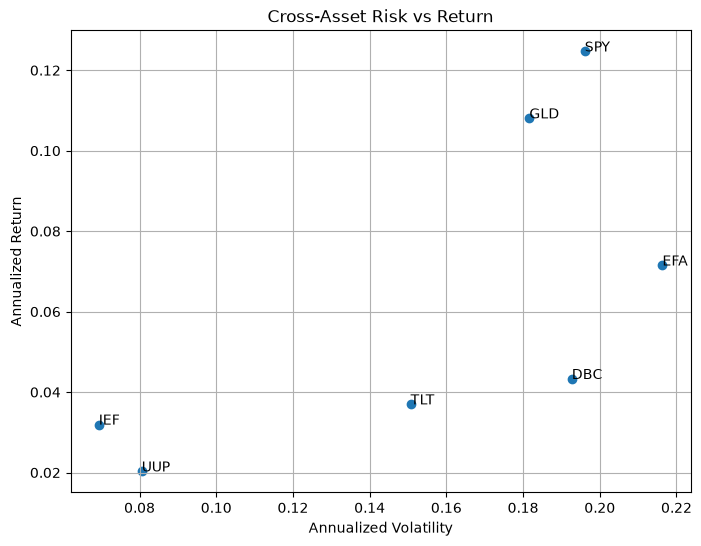

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(asset_stats["Annualized Volatility"],asset_stats["Annualized Return"])

for ticker in asset_stats.index:
    plt.annotate(ticker, (asset_stats.loc[ticker, "Annualized Volatility"], asset_stats.loc[ticker, "Annualized Return"]))

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Cross-Asset Risk vs Return")
plt.grid(True)

plt.show()